# Task 1: Preparación de Datos y Análisis Base
## Task 1.1: Carga y limpieza de datos

Para este análisis, se ha seleccionado el estado de **California (CA)**, cuyo código FIPS de estado es **06**. 
A continuación, se importan las librerías necesarias y se cargan los cuatro archivos requeridos.

In [29]:
# S13 - Redes P2, diapositiva 7: SIG y GeoPandas para capas espaciales.
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar

# Rutas de los archivos en la carpeta data
path_hospitales = 'data/hospitales_eeuu.geojson'
path_condados = 'data/condados_eeuu.geojson'
path_poblacion = 'data/poblacion_condados.csv'
path_estados = 'data/estados_eeuu.geojson'

# Task 1.1.a: Carga de archivos
hospitales = gpd.read_file(path_hospitales)
condados = gpd.read_file(path_condados)
estados = gpd.read_file(path_estados)
poblacion = pd.read_csv(path_poblacion)

# Reporte de cada archivo
print("--- REPORTE DE CARGA DE DATOS ---")
print(f"Hospitales: {len(hospitales)} registros | CRS: {hospitales.crs} | Columnas: {list(hospitales.columns)}")
print(f"Condados: {len(condados)} registros | CRS: {condados.crs} | Columnas: {list(condados.columns)}")
print(f"Estados: {len(estados)} registros | CRS: {estados.crs} | Columnas: {list(estados.columns)}")
print(f"Población: {len(poblacion)} registros | Columnas: {list(poblacion.columns)}")

--- REPORTE DE CARGA DE DATOS ---
Hospitales: 7154 registros | CRS: EPSG:4326 | Columnas: ['nombre', 'tipo', 'ciudad', 'estado', 'condado', 'fips_condado', 'camas_total', 'camas_icu', 'camas_licenciadas', 'ocupacion_total', 'ocupacion_icu', 'geometry']
Condados: 3221 registros | CRS: EPSG:4326 | Columnas: ['fips', 'nombre', 'cod_estado', 'geometry']
Estados: 51 registros | CRS: EPSG:4326 | Columnas: ['nombre', 'codigo', 'pais', 'geometry']
Población: 3246 registros | Columnas: ['fips', 'condado', 'estado', 'lat', 'lon', 'poblacion']


**Task 1.1.b: Limpieza de datos a nivel nacional**
* Se eliminan los registros de población con FIPS >= 80000 y se estandariza a 5 dígitos (string).
* Se calcula el porcentaje de hospitales sin datos en `camas_total` y se filtran para quedarnos solo con los que tienen información válida.

In [30]:
# S13 - Redes P2, diapositiva 12: limpieza de datos espaciales reales en CSV.
# Limpieza de poblacion_condados.csv
# Asegurarnos de que el fips sea numérico para filtrar
poblacion['fips'] = pd.to_numeric(poblacion['fips'], errors='coerce')
poblacion = poblacion[poblacion['fips'] < 80000].copy()

# Convertir a string de 5 dígitos con ceros a la izquierda
poblacion['fips'] = poblacion['fips'].astype(int).astype(str).str.zfill(5)

# Limpieza de hospitales_eeuu.geojson
total_hospitales_orig = len(hospitales)
hospitales_nulos = hospitales['camas_total'].isnull().sum()
pct_nulos = (hospitales_nulos / total_hospitales_orig) * 100

print(f"Porcentaje de hospitales con 'camas_total' nulo: {pct_nulos:.2f}% ({hospitales_nulos} de {total_hospitales_orig})")

# Filtrar hospitales con datos de camas disponibles
hospitales = hospitales[hospitales['camas_total'].notnull()].copy()
print(f"Hospitales restantes a nivel nacional tras limpieza: {len(hospitales)}")

Porcentaje de hospitales con 'camas_total' nulo: 15.24% (1090 de 7154)
Hospitales restantes a nivel nacional tras limpieza: 6064


**Task 1.1.c y 1.1.d: Filtrado por estado (California) y Reproyección**

* Estado elegido: **California (CA)**.
* Se filtran las 3 capas espaciales y se hace el join con los datos poblacionales.
* **Justificación del CRS:** Se proyectan las geometrías a **EPSG:3310 (NAD83 / California Albers)**. Esta proyección cónica equivalente (Albers Equal Area) está diseñada específicamente para abarcar todo el estado de California, minimizando la distorsión del área a lo largo de su gran extensión norte-sur. Esto permite que los cálculos de cobertura en metros (buffers) sean precisos y uniformes en todo el estado, en lugar de usar coordenadas geográficas distorsionadas.

In [31]:
# S13 - Redes P2, diapositiva 7: proyeccion SIG para medir distancias y areas.
# Variables del estado elegido (California)
ESTADO_ELEGIDO = 'CA'
COD_ESTADO_ELEGIDO = '06'
EPSG_PROYECTADO = 3310 # NAD83 / California Albers (Mide en Metros)

# Task 1.1.c: Filtrar por estado
hospitales_est = hospitales[hospitales['estado'] == ESTADO_ELEGIDO].copy()
condados_est = condados[condados['cod_estado'] == COD_ESTADO_ELEGIDO].copy()
limite_est = estados[estados['codigo'] == ESTADO_ELEGIDO].copy()

# Join de condados con población
condados_est = condados_est.merge(poblacion, on='fips', how='inner')

# Verificación de condados
print(f"Hospitales en {ESTADO_ELEGIDO} con datos de camas: {len(hospitales_est)}")
print(f"Condados en {ESTADO_ELEGIDO} tras el merge con población: {len(condados_est)}")

# Task 1.1.d: Reproyectar a CRS en metros (EPSG:3310 para CA)
hospitales_est = hospitales_est.to_crs(epsg=EPSG_PROYECTADO)
condados_est = condados_est.to_crs(epsg=EPSG_PROYECTADO)
limite_est = limite_est.to_crs(epsg=EPSG_PROYECTADO)

print(f"Nuevo CRS (Condados): {condados_est.crs.name}")

Hospitales en CA con datos de camas: 440
Condados en CA tras el merge con población: 58
Nuevo CRS (Condados): NAD83 / California Albers


**Task 1.1.e: Mapa Base**
Mapa con tres capas superpuestas: condados, hospitales clasificados por tipo y el límite estatal.

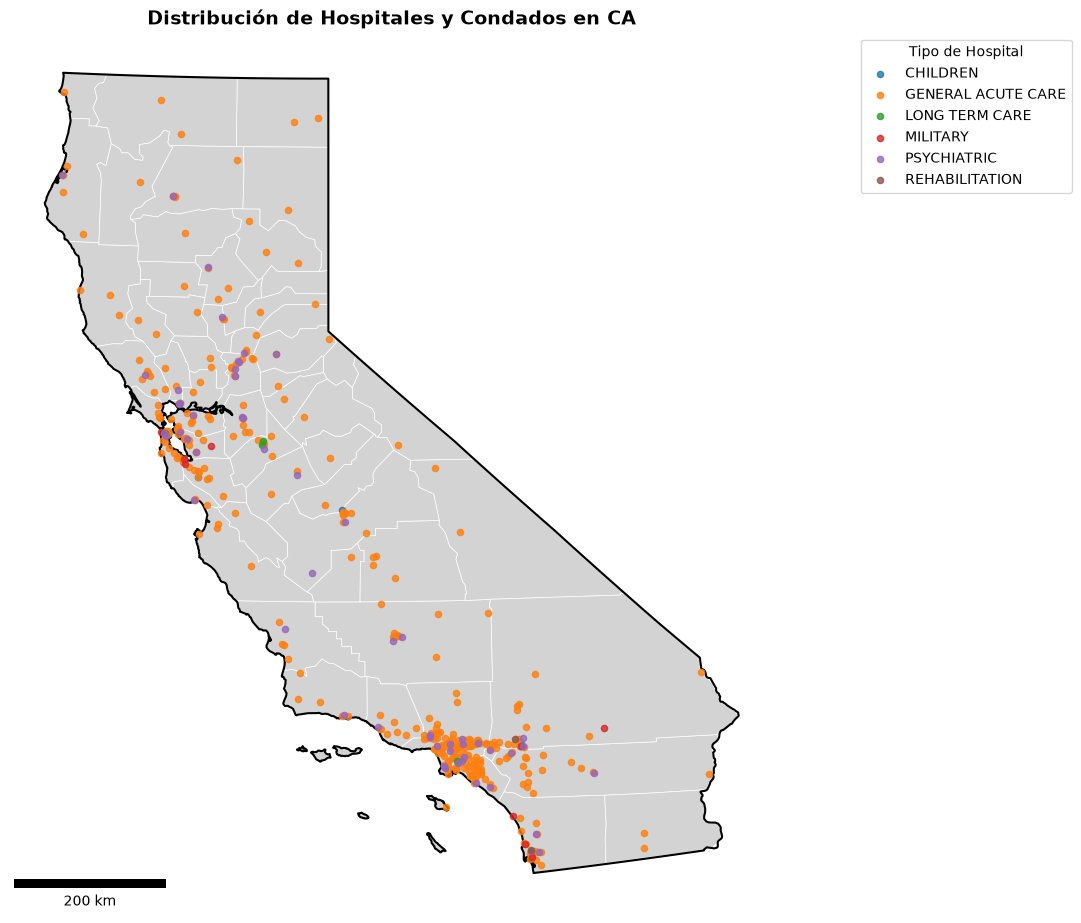

In [32]:
# S13 - Redes P2, diapositiva 8: superposicion de capas administrativas y hospitales.
# Task 1.1.e: Generar mapa de 3 capas
fig, ax = plt.subplots(figsize=(10, 10))

# 1. Capa de condados (gris claro)
condados_est.plot(ax=ax, color='lightgray', edgecolor='white', linewidth=0.5)

# 2. Capa de límite estatal (contorno sin relleno)
limite_est.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1.5)

# 3. Capa de hospitales (puntos de color por tipo)
hospitales_est.plot(ax=ax, column='tipo', legend=True, 
                    cmap='tab10', markersize=20, alpha=0.8,
                    legend_kwds={'loc': 'upper right', 'bbox_to_anchor': (1.4, 1), 'title': 'Tipo de Hospital'})

# Título y ajustes
plt.title(f"Distribución de Hospitales y Condados en {ESTADO_ELEGIDO}", fontsize=14, fontweight='bold')
ax.set_axis_off() # Ocultar ejes de lat/lon proyectados

# Agregar escala gráfica (requiere matplotlib-scalebar)
try:
    # Como el CRS está en metros, la unidad por defecto es metros (dx=1)
    scalebar = ScaleBar(1, units="m", length_fraction=0.2, location="lower left")
    ax.add_artist(scalebar)
except NameError:
    print("Nota: matplotlib-scalebar no está importado. La escala gráfica no se dibujará.")

plt.tight_layout()
plt.show()

## Task 1.2: Estadísticas por condado

Se calcula y reporta en una tabla las siguientes estadísticas por condado: número de hospitales, camas totales, camas UCI, población total, camas totales por cada 10,000 habitantes, y camas UCI por cada 10,000 habitantes. Para condados sin hospitales se asigno cero en las columnas numéricas.

In [33]:
# S13 - Redes P2, diapositiva 8: agregacion de atributos por unidad administrativa.
# --- TASK 1.2: Estadísticas por condado ---

# Agrupar hospitales por condado para sumar capacidades
hosp_stats = hospitales_est.groupby('fips_condado').agg(
    num_hospitales=('nombre', 'count'),
    camas_totales=('camas_total', 'sum'),
    camas_uci=('camas_icu', 'sum')
).reset_index()

# Unir con la tabla de condados (Left join para no perder condados sin hospitales)
condados_stats = condados_est.merge(hosp_stats, left_on='fips', right_on='fips_condado', how='left')

# Rellenar con 0 los valores numéricos para condados sin hospitales
cols_fill = ['num_hospitales', 'camas_totales', 'camas_uci']
condados_stats[cols_fill] = condados_stats[cols_fill].fillna(0)

# Calcular métricas por cada 10,000 habitantes
condados_stats['camas_totales_10k'] = (condados_stats['camas_totales'] / condados_stats['poblacion']) * 10000
condados_stats['camas_uci_10k'] = (condados_stats['camas_uci'] / condados_stats['poblacion']) * 10000

# Mostrar las primeras filas de la tabla general
columnas_reporte = ['nombre', 'num_hospitales', 'camas_totales', 'camas_uci', 'poblacion', 'camas_totales_10k', 'camas_uci_10k']
print("--- TABLA GENERAL DE ESTADÍSTICAS POR CONDADO (Primeros 5 registros) ---")
display(condados_stats[columnas_reporte].head(5))

# 1.2.a: 5 condados con menor cantidad de camas por habitante (población > 10,000)
top5_menor = condados_stats[condados_stats['poblacion'] > 10000].sort_values('camas_totales_10k', ascending=True).head(5)
print("\n--- 1.2.a: 5 condados con menor concentración de camas ---")
display(top5_menor[['nombre', 'poblacion', 'camas_totales', 'camas_totales_10k']])

# 1.2.b: 5 condados con mayor concentración de camas
top5_mayor = condados_stats.sort_values('camas_totales_10k', ascending=False).head(5)
print("\n--- 1.2.b: 5 condados con mayor concentración de camas ---")
display(top5_mayor[['nombre', 'poblacion', 'camas_totales', 'camas_totales_10k']])

--- TABLA GENERAL DE ESTADÍSTICAS POR CONDADO (Primeros 5 registros) ---


,nombre,num_hospitales,camas_totales,camas_uci,poblacion,camas_totales_10k,camas_uci_10k
0,Amador,1.0,52.0,6.0,39752.0,13.081103,1.509358
1,Glenn,1.0,15.0,0.0,28393.0,5.282992,0.000000
2,Lake,2.0,50.0,8.0,64386.0,7.765663,1.242506
3,Mariposa,1.0,18.0,0.0,17203.0,10.463291,0.000000
4,Napa,3.0,318.0,48.0,137744.0,23.086305,3.484725



--- 1.2.a: 5 condados con menor concentración de camas ---


,nombre,poblacion,camas_totales,camas_totales_10k
24,Sutter,96971.0,30.0,3.093708
1,Glenn,28393.0,15.0,5.282992
27,Calaveras,45905.0,25.0,5.446030
19,Yolo,220500.0,125.0,5.668934
25,Tehama,65084.0,49.0,7.528732



--- 1.2.b: 5 condados con mayor concentración de camas ---


,nombre,poblacion,camas_totales,camas_totales_10k
52,San Luis Obispo,283111.0,1619.0,57.186051
18,San Francisco,881549.0,2885.0,32.726485
5,Shasta,180080.0,571.0,31.708130
44,Fresno,999101.0,2983.0,29.856841
33,Madera,157327.0,464.0,29.492713


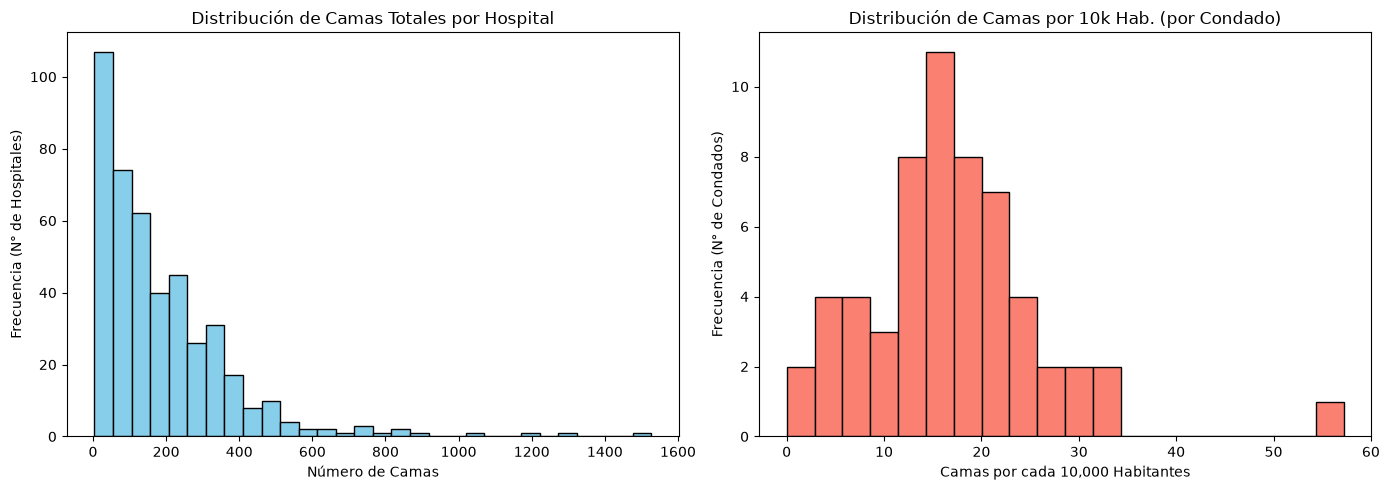

In [34]:
# S12 - Redes P1, diapositiva 5: distribucion de grado como referencia para estudiar heterogeneidad.
# --- TASK 1.2.c: Graficar distribuciones ---

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma 1: Camas por hospital (de la capa de hospitales original en CA)
hospitales_est['camas_total'].plot(kind='hist', bins=30, ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Distribución de Camas Totales por Hospital')
axes[0].set_xlabel('Número de Camas')
axes[0].set_ylabel('Frecuencia (N° de Hospitales)')

# Histograma 2: Camas por 10k habitantes por condado
condados_stats['camas_totales_10k'].plot(kind='hist', bins=20, ax=axes[1], color='salmon', edgecolor='black')
axes[1].set_title('Distribución de Camas por 10k Hab. (por Condado)')
axes[1].set_xlabel('Camas por cada 10,000 Habitantes')
axes[1].set_ylabel('Frecuencia (N° de Condados)')

plt.tight_layout()
plt.show()

## Task 1.3: Análisis de Buffer de Cobertura

Se generan los buffers de 10 km, 25 km y 50 km, se calcula la población cubierta y se realiza el mapa

In [35]:
# S13 - Redes P2, diapositiva 8: buffers y operaciones espaciales de cobertura.
# --- TASK 1.3: Análisis de Buffer de Cobertura ---

import numpy as np

# 1.3.a: Generar buffers unificados para 10 km, 25 km y 50 km
radios_km = [10, 25, 50]
buffers_unificados = {}

for radio in radios_km:
    # Convertir km a metros (el CRS 3310 usa metros)
    radio_m = radio * 1000
    # Crear buffer por hospital y unir todas las geometrías en un solo polígono
    buffer_unificado = hospitales_est.geometry.buffer(radio_m).unary_union
    buffers_unificados[radio] = buffer_unificado

# 1.3.b: Calcular fracción de población cubierta por cada radio
resultados_cobertura = []
poblacion_total_est = condados_est['poblacion'].sum()

for radio, area_cubierta in buffers_unificados.items():
    pob_cubierta_estimada = 0
    
    for idx, condado in condados_est.iterrows():
        geom_condado = condado.geometry
        
        # Intersección entre el condado y el área cubierta total
        interseccion = geom_condado.intersection(area_cubierta)
        
        if not interseccion.is_empty:
            # Fracción del área del condado que está cubierta
            fraccion_area = interseccion.area / geom_condado.area
            # Asumimos distribución uniforme de la población
            pob_cubierta_estimada += condado['poblacion'] * fraccion_area
            
    pct_cobertura = (pob_cubierta_estimada / poblacion_total_est) * 100
    
    resultados_cobertura.append({
        'Radio (km)': radio,
        'Población Cubierta': int(pob_cubierta_estimada),
        'Población Total': int(poblacion_total_est),
        'Cobertura (%)': round(pct_cobertura, 2)
    })

df_cobertura = pd.DataFrame(resultados_cobertura)
print("--- 1.3.b: RESULTADOS DE COBERTURA POBLACIONAL ---")
display(df_cobertura)

--- 1.3.b: RESULTADOS DE COBERTURA POBLACIONAL ---


,Radio (km),Población Cubierta,Población Total,Cobertura (%)
0,10,14994892,39512223,37.95
1,25,28129870,39512223,71.19
2,50,36356744,39512223,92.01


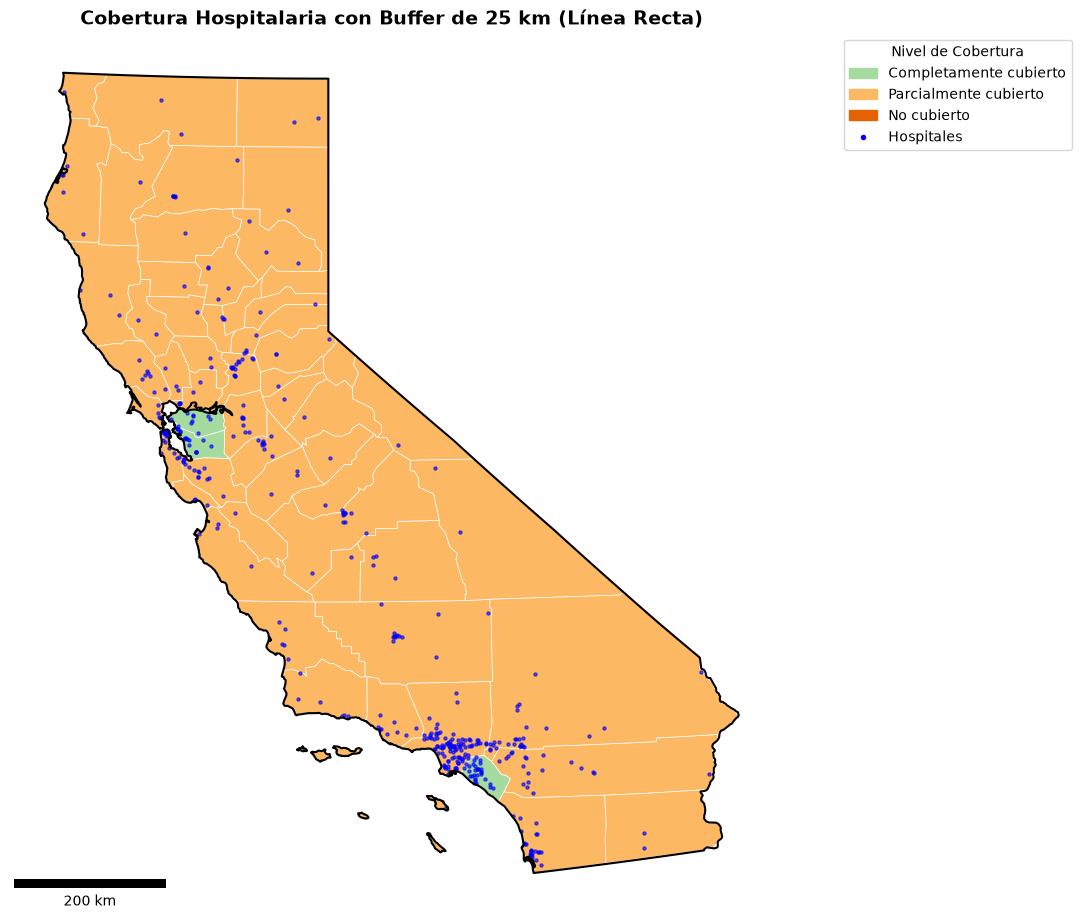

In [36]:
# S13 - Redes P2, diapositiva 13: identificacion de cobertura y brechas de acceso.
# 1.3.c: Generar mapa de cobertura para el radio de 25 km
radio_mapa = 25
area_25km = buffers_unificados[radio_mapa]

# Determinar el estado de cobertura de cada condado
def clasificar_cobertura(geom):
    interseccion = geom.intersection(area_25km)
    if interseccion.area == 0:
        return 'No cubierto'
    elif interseccion.area >= geom.area * 0.99: # 99% para evitar errores de redondeo
        return 'Completamente cubierto'
    else:
        return 'Parcialmente cubierto'

condados_est['estado_cobertura'] = condados_est.geometry.apply(clasificar_cobertura)

# Graficar
fig, ax = plt.subplots(figsize=(10, 10))

# Colores divergentes para resaltar vulnerabilidad
color_dict = {
    'Completamente cubierto': '#a6dba0', # Verde claro
    'Parcialmente cubierto': '#fdb863',  # Naranja claro
    'No cubierto': '#e66101'             # Naranja oscuro / Rojo
}

for estado, color in color_dict.items():
    subset = condados_est[condados_est['estado_cobertura'] == estado]
    if not subset.empty:
        subset.plot(ax=ax, color=color, edgecolor='white', linewidth=0.5, label=estado)

# Agregar los hospitales encima
hospitales_est.plot(ax=ax, color='blue', markersize=5, alpha=0.6, label='Hospitales')

# Limites estatales
limite_est.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1.5)

plt.title('Cobertura Hospitalaria con Buffer de 25 km (Línea Recta)', fontsize=14, fontweight='bold')
ax.set_axis_off()

# Leyenda manual para los colores
import matplotlib.patches as mpatches
legend_patches = [mpatches.Patch(color=color, label=estado) for estado, color in color_dict.items()]
# Añadir el punto azul a la leyenda
legend_patches.append(plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=5, label='Hospitales'))
ax.legend(handles=legend_patches, loc='upper right', bbox_to_anchor=(1.4, 1), title="Nivel de Cobertura")

# Escala gráfica
try:
    scalebar = ScaleBar(1, units="m", length_fraction=0.2, location="lower left")
    ax.add_artist(scalebar)
except NameError:
    pass

plt.tight_layout()
plt.show()

## Task 2.1: Análisis de Distancia al Hospital más Cercano

Se evalua qué tan sensible es nuestra conclusión a la simplificación del área circular, midiendo distancias exactas desde los centroides de cada condado y creando la curva de cobertura acumulada.

--- 2.1.a: Top 10 Condados con mayor distancia (km) desde su centroide al hospital más cercano ---


,nombre,dist_min_km
0,San Bernardino,69.318321
1,Inyo,58.972679
2,Alpine,37.914754
3,San Benito,37.537444
4,Tuolumne,37.150464
5,Madera,36.728173
6,Shasta,35.032546
7,Mono,33.505281
8,Placer,33.330553
9,Kings,30.870548



Calculando curva de cobertura (esto puede tomar un momento)...


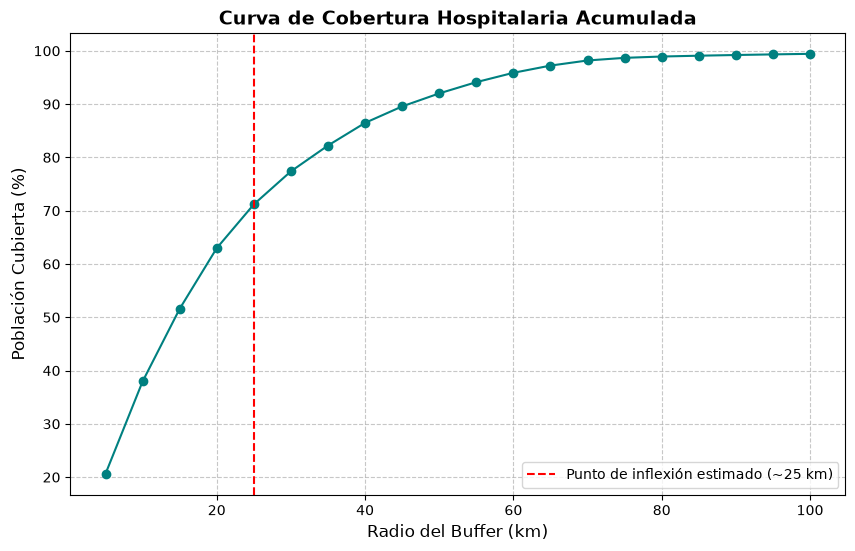


--- 2.1.c: Información del hospital más cercano para los 5 condados más alejados ---


,nombre,dist_min_km,hosp_cercano_nombre,hosp_cercano_tipo,hosp_cercano_camas
0,San Bernardino,69.318321,ROBERT E. BUSH NAVAL HOSPITAL,MILITARY,19.0
1,Inyo,58.972679,SOUTHERN INYO HOSPITAL,GENERAL ACUTE CARE,4.0
2,Alpine,37.914754,BARTON MEMORIAL HOSPITAL,GENERAL ACUTE CARE,63.0
3,San Benito,37.537444,HAZEL HAWKINS MEMORIAL HOSPITAL,GENERAL ACUTE CARE,49.0
4,Tuolumne,37.150464,SONORA REGIONAL MEDICAL CENTER - GREENLEY,GENERAL ACUTE CARE,84.0


In [37]:
# S13 - Redes P2, diapositiva 13: comparacion de accesibilidad mediante distancias.
# --- TASK 2.1: Sensibilidad de la cobertura y Curva Acumulada ---

# 2.1.a Calcular distancia desde el centroide del condado al hospital más cercano
# Calculamos los centroides
condados_est['centroide'] = condados_est.geometry.centroid

# Función para encontrar la distancia mínima al hospital más cercano
def distancia_minima_hospital(punto):
    # Calcular distancia a todos los hospitales
    distancias = hospitales_est.geometry.distance(punto)
    return distancias.min() / 1000  # Convertir a kilómetros

condados_est['dist_min_km'] = condados_est['centroide'].apply(distancia_minima_hospital)

# Los 10 condados con mayor distancia
top10_lejanos = condados_est.sort_values('dist_min_km', ascending=False).head(10)
print("--- 2.1.a: Top 10 Condados con mayor distancia (km) desde su centroide al hospital más cercano ---")
display(top10_lejanos[['nombre', 'dist_min_km']].reset_index(drop=True))


# 2.1.b: Curva de cobertura acumulada (5 a 100 km)
radios_curva = range(5, 105, 5)
porcentajes_cobertura = []

print("\nCalculando curva de cobertura (esto puede tomar un momento)...")
for r in radios_curva:
    buffer_union = hospitales_est.geometry.buffer(r * 1000).unary_union
    pob_cub = 0
    for idx, condado in condados_est.iterrows():
        interseccion = condado.geometry.intersection(buffer_union)
        if not interseccion.is_empty:
            pob_cub += condado['poblacion'] * (interseccion.area / condado.geometry.area)
    porcentajes_cobertura.append((pob_cub / poblacion_total_est) * 100)

# Graficar la curva
plt.figure(figsize=(10, 6))
plt.plot(radios_curva, porcentajes_cobertura, marker='o', linestyle='-', color='teal')
plt.title('Curva de Cobertura Hospitalaria Acumulada', fontsize=14, fontweight='bold')
plt.xlabel('Radio del Buffer (km)', fontsize=12)
plt.ylabel('Población Cubierta (%)', fontsize=12)

# Punto de inflexión aproximado (donde la pendiente baja drásticamente)
# Observaremos visualmente dónde deja de crecer rápidamente, suele estar entre 20 y 30 km.
plt.axvline(x=25, color='red', linestyle='--', label='Punto de inflexión estimado (~25 km)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 2.1.c Identificar el tipo y capacidad del hospital más cercano para los 5 más alejados
def info_hospital_mas_cercano(punto):
    distancias = hospitales_est.geometry.distance(punto)
    idx_min = distancias.idxmin()
    hosp_cercano = hospitales_est.loc[idx_min]
    return pd.Series([hosp_cercano['nombre'], hosp_cercano['tipo'], hosp_cercano['camas_total']])

top5_lejanos = top10_lejanos.head(5).copy()
top5_lejanos[['hosp_cercano_nombre', 'hosp_cercano_tipo', 'hosp_cercano_camas']] = top5_lejanos['centroide'].apply(info_hospital_mas_cercano)

print("\n--- 2.1.c: Información del hospital más cercano para los 5 condados más alejados ---")
display(top5_lejanos[['nombre', 'dist_min_km', 'hosp_cercano_nombre', 'hosp_cercano_tipo', 'hosp_cercano_camas']].reset_index(drop=True))

## Task 2.2: Construcción del Índice de Vulnerabilidad

Se combina la distancia, la escasez de camas per cápita y la ocupación hospitalaria en un solo índice compuesto.

--- 2.2.c: Top 10 Condados con mayor Índice de Vulnerabilidad ---


,nombre,indice_vuln,categoria_vuln
0,San Bernardino,0.700000,Muy Alta
1,Inyo,0.639546,Muy Alta
2,Sierra,0.556440,Muy Alta
3,Alpine,0.551428,Muy Alta
4,Glenn,0.397813,Muy Alta
5,San Diego,0.364258,Muy Alta
6,Madera,0.363855,Muy Alta
7,Tuolumne,0.341483,Muy Alta
8,Humboldt,0.303309,Muy Alta
9,Placer,0.301353,Muy Alta


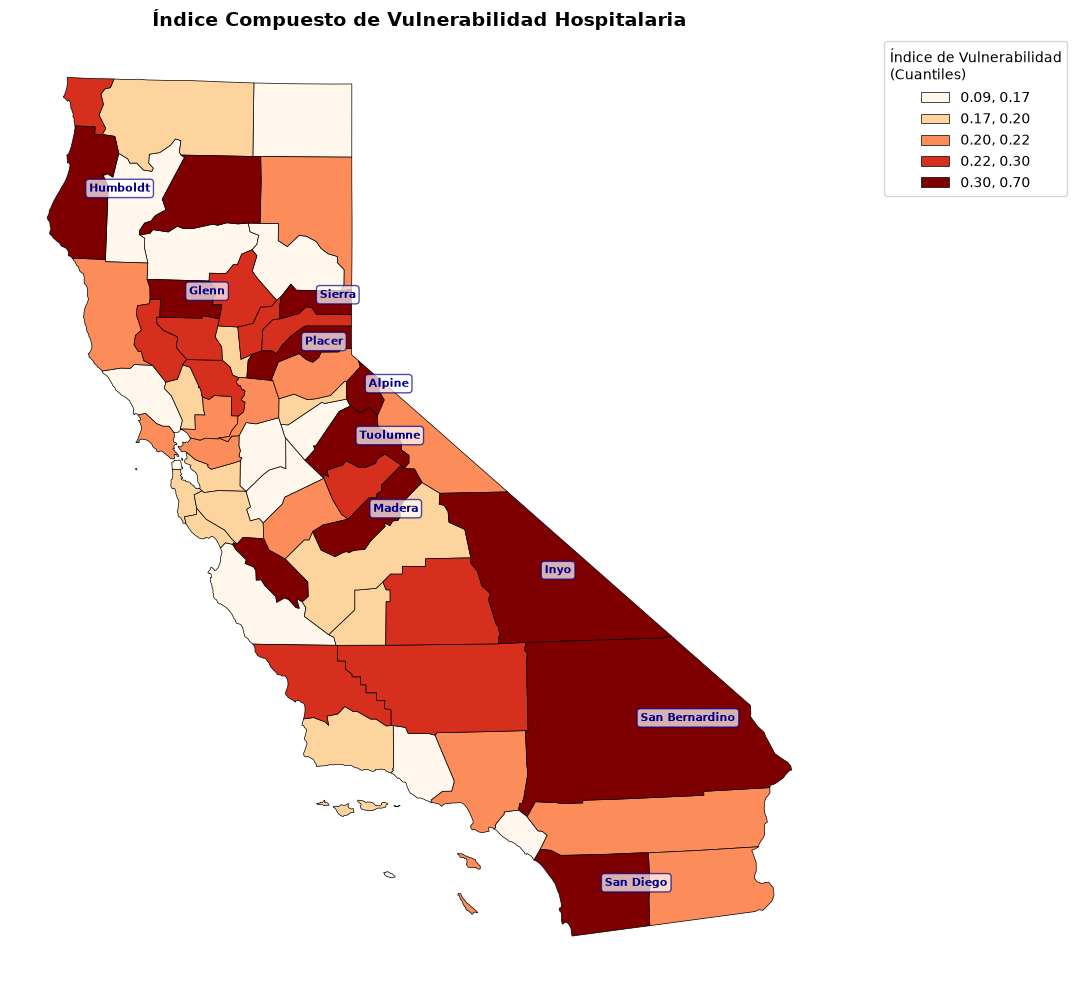

In [38]:
# S12 - Redes P1, diapositiva 5: integracion de metricas de la red.
# --- TASK 2.2: Índice Compuesto de Vulnerabilidad ---

# Asegurarnos de que condados_est tenga la columna 'camas_totales'
# usando la tabla que creamos en el Task 1.2 (condados_stats)
if 'camas_totales' not in condados_est.columns:
    # Traemos solo la columna de camas_totales basándonos en el fips
    temp_camas = condados_stats[['fips', 'camas_totales']].copy()
    condados_est = condados_est.merge(temp_camas, on='fips', how='left')
    condados_est['camas_totales'] = condados_est['camas_totales'].fillna(0)

# Componente 1: Distancia al hospital más cercano (ya calculada en 2.1.a: dist_min_km)
comp1_raw = condados_est['dist_min_km'].copy()

# Componente 2: Inverso de camas totales per cápita
# Sumar un valor pequeño para evitar división por cero en condados sin camas
condados_est['camas_per_capita'] = condados_est['camas_totales'] / condados_est['poblacion']
comp2_raw = 1 / (condados_est['camas_per_capita'] + 1e-9)

# Asignar el valor máximo a los condados que tenían 0 camas originalmente
comp2_raw[condados_est['camas_totales'] == 0] = comp2_raw.max()

# Componente 3: Tasa de ocupación promedio en hospitales a menos de 50 km del centroide
def ocupacion_50km(punto):
    # Obtener distancias a todos los hospitales
    distancias = hospitales_est.geometry.distance(punto)
    # Filtrar los que están a <= 50,000 metros (50 km)
    hospitales_cercanos = hospitales_est[distancias <= 50000]
    
    if len(hospitales_cercanos) == 0:
        return np.nan # Luego lo rellenaremos con el máximo
    
    # Calcular el promedio de ocupación total de esos hospitales
    promedio_ocupacion = hospitales_cercanos['ocupacion_total'].mean()
    return promedio_ocupacion

comp3_raw = condados_est['centroide'].apply(ocupacion_50km)
# Rellenar condados sin hospitales a < 50km o cuyo promedio dio NaN con el valor máximo
comp3_raw = comp3_raw.fillna(comp3_raw.max())

# Función para normalizar min-max (0 a 1)
def min_max_normalize(series):
    return (series - series.min()) / (series.max() - series.min())

# 2.2.a Aplicar Normalización
condados_est['C1_norm'] = min_max_normalize(comp1_raw)
condados_est['C2_norm'] = min_max_normalize(comp2_raw)
condados_est['C3_norm'] = min_max_normalize(comp3_raw)

# 2.2.b Cálculo del Índice Compuesto
# Pesos propuestos (deben sumar 1.0): 
# W1 (Distancia) = 0.4: Llegar al hospital es el primer paso crítico en emergencias.
# W2 (Falta de Camas) = 0.3: Si llegas pero no hay camas, la atención peligra.
# W3 (Alta Ocupación) = 0.3: Refleja el estrés operativo real del sistema cercano.
W1, W2, W3 = 0.4, 0.3, 0.3

condados_est['indice_vuln'] = (condados_est['C1_norm'] * W1) + \
                              (condados_est['C2_norm'] * W2) + \
                              (condados_est['C3_norm'] * W3)

# 2.2.c Generar Mapa Coroplético (Quintiles)
# Clasificación por quintiles usando cuantiles de Pandas
condados_est['categoria_vuln'] = pd.qcut(condados_est['indice_vuln'], 5, 
                                         labels=['Muy Baja', 'Baja', 'Media', 'Alta', 'Muy Alta'])

# Extraer los 10 condados más vulnerables
top10_vuln = condados_est.sort_values('indice_vuln', ascending=False).head(10)
print("--- 2.2.c: Top 10 Condados con mayor Índice de Vulnerabilidad ---")
display(top10_vuln[['nombre', 'indice_vuln', 'categoria_vuln']].reset_index(drop=True))

# Dibujar el mapa
fig, ax = plt.subplots(figsize=(12, 10))

# Mapeo coroplético usando la columna original numérica, con esquema de cuantiles
condados_est.plot(column='indice_vuln', ax=ax, legend=True,
                  cmap='OrRd', scheme='quantiles', edgecolor='black', linewidth=0.5,
                  legend_kwds={'loc': 'upper right', 'bbox_to_anchor': (1.3, 1), 
                               'title': 'Índice de Vulnerabilidad\n(Cuantiles)'})

# Agregar etiquetas de nombre solo para el Top 10
for x, y, label in zip(top10_vuln.geometry.centroid.x, top10_vuln.geometry.centroid.y, top10_vuln['nombre']):
    ax.annotate(label, xy=(x, y), xytext=(3, 3), textcoords="offset points", 
                fontsize=8, fontweight='bold', color='darkblue',
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="darkblue", lw=1, alpha=0.7))

plt.title('Índice Compuesto de Vulnerabilidad Hospitalaria', fontsize=14, fontweight='bold')
ax.set_axis_off()
plt.tight_layout()
plt.show()

## Task 2.3: Problema de Localización de Cobertura Máxima (MCLP)

Implementación de un algoritmo voraz (greedy) para proponer la ubicación de 3 nuevos hospitales en una grilla de puntos candidatos separados por 50 km.

Puntos candidatos generados dentro de CA: 162

Ejecutando algoritmo voraz para 3 nuevos hospitales...
Hospital 1: Punto 100 seleccionado. Población adicional cubierta: 844905
Hospital 2: Punto 135 seleccionado. Población adicional cubierta: 593299
Hospital 3: Punto 136 seleccionado. Población adicional cubierta: 396049

Resumen Final:
Población total adicional cubierta: 1834254
Porcentaje de cobertura total final (25km): 75.84%


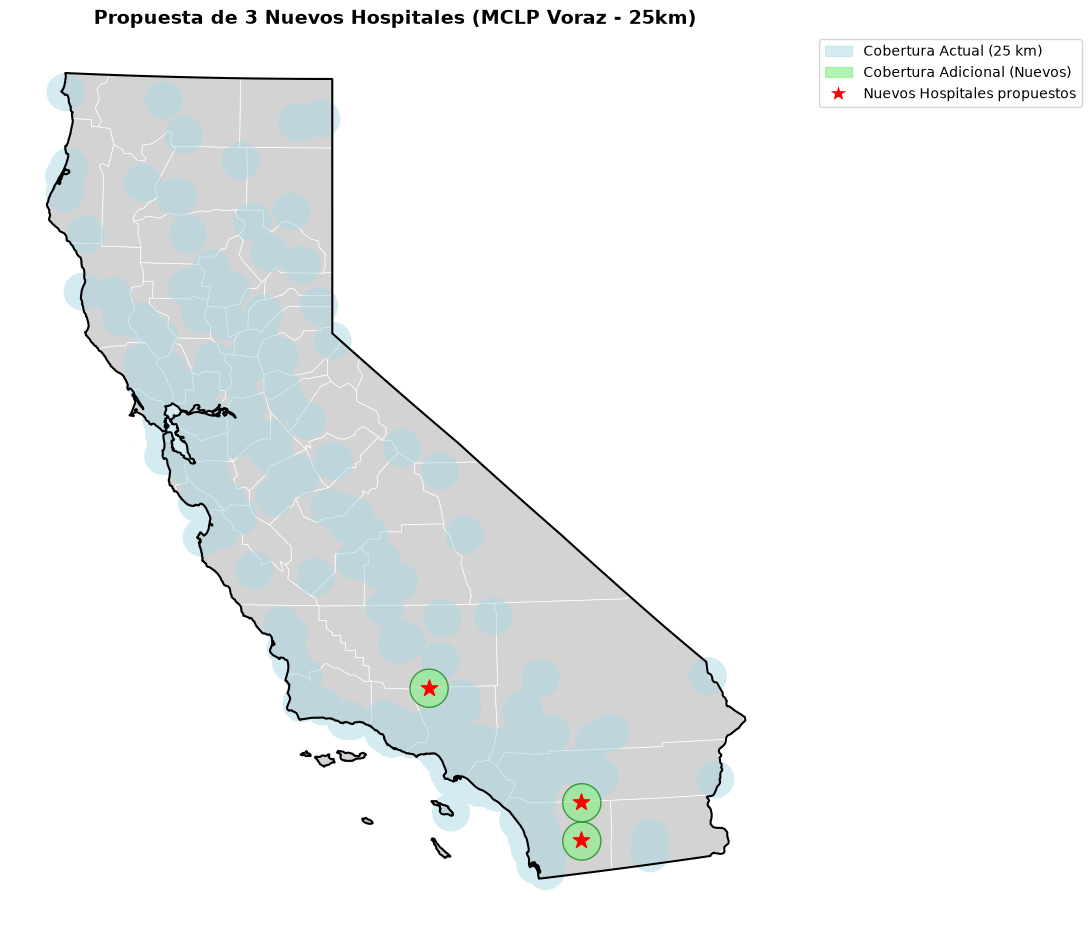

In [39]:
# S13 - Redes P2, diapositiva 9: optimizacion MCLP para maximizar poblacion cubierta.
# --- TASK 2.3: Algoritmo MCLP Voraz ---

from shapely.geometry import Point

# 2.3.a Generar grilla de puntos candidatos (Resolución: 50 km)
xmin, ymin, xmax, ymax = limite_est.total_bounds
resolucion = 50000  # 50 km en metros

x_coords = np.arange(xmin, xmax, resolucion)
y_coords = np.arange(ymin, ymax, resolucion)

puntos_grilla = [Point(x, y) for x in x_coords for y in y_coords]
gdf_candidatos = gpd.GeoDataFrame(geometry=puntos_grilla, crs=EPSG_PROYECTADO)

# Intersección espacial para conservar solo puntos dentro del estado
gdf_candidatos = gpd.sjoin(gdf_candidatos, limite_est, how="inner", predicate="intersects")
gdf_candidatos = gdf_candidatos[['geometry']].reset_index(drop=True)

print(f"Puntos candidatos generados dentro de {ESTADO_ELEGIDO}: {len(gdf_candidatos)}")

# 2.3.b y 2.3.c: Algoritmo voraz para ubicar 3 hospitales (Buffer = 25 km)
radio_cobertura = 25000  # 25 km en metros
hospitales_seleccionados = []
poblacion_total_adicional = 0

# Obtener la cobertura actual (Task 1.3)
cobertura_actual = buffers_unificados[25] # El buffer unificado de 25km creado anteriormente

print("\nEjecutando algoritmo voraz para 3 nuevos hospitales...")

for i in range(3):
    max_pob_adicional = 0
    mejor_punto_idx = -1
    mejor_cobertura_nueva = None
    
    for idx, candidato in gdf_candidatos.iterrows():
        # Si el punto ya fue seleccionado, lo saltamos
        if idx in hospitales_seleccionados:
            continue
            
        buffer_candidato = candidato.geometry.buffer(radio_cobertura)
        
        # Calcular el área NUEVA que este buffer cubriría (que no está en cobertura_actual)
        nueva_area_cobertura = buffer_candidato.difference(cobertura_actual)
        
        # Si no añade área nueva significativa, pasamos
        if nueva_area_cobertura.is_empty:
            continue
            
        pob_adicional_candidato = 0
        
        # Calcular cuánta población vive en esta nueva área de cobertura
        for _, condado in condados_est.iterrows():
            interseccion = condado.geometry.intersection(nueva_area_cobertura)
            if not interseccion.is_empty:
                fraccion_area = interseccion.area / condado.geometry.area
                pob_adicional_candidato += condado['poblacion'] * fraccion_area
                
        # Actualizar si encontramos un punto que cubra más población
        if pob_adicional_candidato > max_pob_adicional:
            max_pob_adicional = pob_adicional_candidato
            mejor_punto_idx = idx
            mejor_cobertura_nueva = nueva_area_cobertura
            
    # Guardar el mejor punto de esta iteración
    hospitales_seleccionados.append(mejor_punto_idx)
    poblacion_total_adicional += max_pob_adicional
    
    # Actualizar la cobertura total (unir la nueva área a la cobertura actual)
    cobertura_actual = cobertura_actual.union(mejor_cobertura_nueva)
    
    print(f"Hospital {i+1}: Punto {mejor_punto_idx} seleccionado. Población adicional cubierta: {int(max_pob_adicional)}")

# Calcular porcentaje final
pob_base_cubierta = df_cobertura[df_cobertura['Radio (km)'] == 25]['Población Cubierta'].values[0]
pob_final_cubierta = pob_base_cubierta + poblacion_total_adicional
pct_final = (pob_final_cubierta / poblacion_total_est) * 100

print(f"\nResumen Final:")
print(f"Población total adicional cubierta: {int(poblacion_total_adicional)}")
print(f"Porcentaje de cobertura total final (25km): {pct_final:.2f}%")

# Graficar los 3 nuevos puntos sobre el mapa de cobertura base
fig, ax = plt.subplots(figsize=(10, 10))

# Capa de condados
condados_est.plot(ax=ax, color='lightgray', edgecolor='white', linewidth=0.5)

# Capa de cobertura base (25km)
gpd.GeoSeries([buffers_unificados[25]]).plot(ax=ax, color='lightblue', alpha=0.5, label='Cobertura Base')

# Capa de nueva cobertura (unión de los 3 nuevos buffers)
gdf_nuevos = gdf_candidatos.iloc[hospitales_seleccionados]
nuevos_buffers = gdf_nuevos.geometry.buffer(radio_cobertura).unary_union
gpd.GeoSeries([nuevos_buffers]).plot(ax=ax, color='lightgreen', alpha=0.7, edgecolor='green', label='Nueva Cobertura')

# Puntos candidatos seleccionados
gdf_nuevos.plot(ax=ax, color='red', marker='*', markersize=150, label='Nuevos Hospitales')

# Limites
limite_est.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1.5)

plt.title('Propuesta de 3 Nuevos Hospitales (MCLP Voraz - 25km)', fontsize=14, fontweight='bold')
ax.set_axis_off()

# Leyenda
legend_patches = [
    mpatches.Patch(color='lightblue', alpha=0.5, label='Cobertura Actual (25 km)'),
    mpatches.Patch(color='lightgreen', alpha=0.7, label='Cobertura Adicional (Nuevos)'),
    plt.Line2D([0], [0], marker='*', color='w', markerfacecolor='red', markersize=15, label='Nuevos Hospitales propuestos')
]
ax.legend(handles=legend_patches, loc='upper right', bbox_to_anchor=(1.4, 1))

plt.tight_layout()
plt.show()

## Task 3: Comparación con Isocronas de Tiempo de Viaje (OSMnx)

Se calcula isocronas reales de tiempo de viaje (usando OSMnx) para los hospitales en las zonas más vulnerables y se compara esto con los buffers circulares rectilíneos.

Descargando red vial para el hospital: DESERT VALLEY HOSPITAL en el condado San Bernardino...
Por favor espera, esto puede tardar un par de minutos...

--- 3.1.a: RESULTADOS DE COMPARACIÓN ---
Hospital analizado: DESERT VALLEY HOSPITAL
Área cubierta por Buffer circular (25 km en línea recta): 1960.34 km²
Área cubierta por Isocrona (30 mins por red vial real): 1697.73 km²
Diferencia: El buffer asume un área 1.15 veces mayor que la isocrona real.


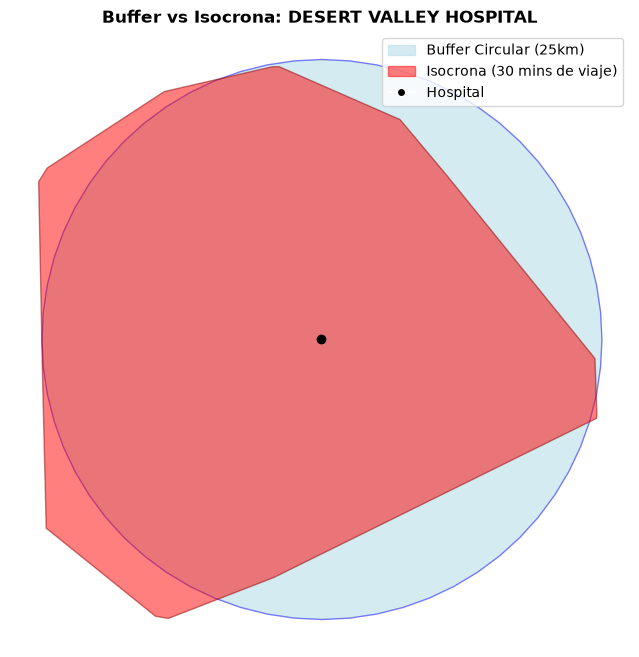

In [40]:
# S13 - Redes P2, diapositiva 10: movilidad y tiempos de viaje en la red vial.
# S13 - Redes P2, diapositiva 12: datos reales de OpenStreetMap.
# S13 - Redes P2, diapositiva 13: isocronas para analizar cobertura hospitalaria.
# S13 - Redes P2, diapositiva 14: el espacio como estructura de interaccion.
# --- TASK 3.1: Comparación con Isocronas de Tiempo de Viaje (OSMnx) ---

import osmnx as ox
import networkx as nx
import warnings
warnings.filterwarnings('ignore') # Ocultar advertencias de deprecación

# Extraemos el condado MÁS vulnerable según el Task 2.2
condado_mas_vulnerable = top10_vuln.iloc[0]
nombre_condado_vuln = condado_mas_vulnerable['nombre']

# Buscar hospitales que estén DENTRO de ese condado
# Primero aseguramos que los CRS coincidan
hospitales_est = hospitales_est.to_crs(condados_est.crs)
hospitales_en_vuln = gpd.sjoin(hospitales_est, 
                               condados_est[condados_est['nombre'] == nombre_condado_vuln], 
                               how="inner", predicate="intersects")

if len(hospitales_en_vuln) > 0:
    # Elegir el primer hospital disponible
    hospital_elegido = hospitales_en_vuln.iloc[0]
    coord_hospital = (hospital_elegido.geometry.y, hospital_elegido.geometry.x) # (lat, lon) en CRS proyectado
    
    # OSMnx requiere lat/lon en WGS84 (EPSG:4326) para descargar el grafo.
    hosp_wgs84 = gpd.GeoSeries([hospital_elegido.geometry], crs=EPSG_PROYECTADO).to_crs(epsg=4326)
    coord_wgs84 = (hosp_wgs84.y.iloc[0], hosp_wgs84.x.iloc[0]) # (lat, lon)
    
    print(f"Descargando red vial para el hospital: {hospital_elegido['nombre_left']} en el condado {nombre_condado_vuln}...")
    print("Por favor espera, esto puede tardar un par de minutos...")
    
    try:
        # Descargamos un grafo de red manejable (25 km a la redonda del hospital)
        G = ox.graph_from_point(coord_wgs84, dist=25000, network_type='drive')
        
        # Imputar velocidades y tiempos de viaje en el grafo
        G = ox.add_edge_speeds(G)
        G = ox.add_edge_travel_times(G)
        
        # Encontrar el nodo más cercano al hospital
        nodo_origen = ox.distance.nearest_nodes(G, coord_wgs84[1], coord_wgs84[0])
        
        # Calcular isocrona de 30 minutos (1800 segundos)
        tiempo_max = 1800 
        # Encontrar los subgrafos accesibles dentro del tiempo maximo
        subgrafo = nx.ego_graph(G, nodo_origen, radius=tiempo_max, distance='travel_time')
        nodos_isocrona = [Point((data['x'], data['y'])) for node, data in subgrafo.nodes(data=True)]
        
        # Crear un polígono convexo a partir de los nodos accesibles
        gdf_nodos = gpd.GeoDataFrame(geometry=nodos_isocrona, crs="EPSG:4326")
        isocrona_30min = gdf_nodos.geometry.unary_union.convex_hull
        
        # Proyectar la isocrona de vuelta al CRS en metros
        isocrona_30min_proj = gpd.GeoSeries([isocrona_30min], crs="EPSG:4326").to_crs(epsg=EPSG_PROYECTADO).iloc[0]
        
        # Generar Buffer Circular Rectilíneo de 25km para comparar
        buffer_25km = hospital_elegido.geometry.buffer(25000)
        
        # Calcular áreas
        area_isocrona_km2 = isocrona_30min_proj.area / 1e6
        area_buffer_km2 = buffer_25km.area / 1e6
        
        print("\n--- 3.1.a: RESULTADOS DE COMPARACIÓN ---")
        print(f"Hospital analizado: {hospital_elegido['nombre_left']}")
        print(f"Área cubierta por Buffer circular (25 km en línea recta): {area_buffer_km2:.2f} km²")
        print(f"Área cubierta por Isocrona (30 mins por red vial real): {area_isocrona_km2:.2f} km²")
        print(f"Diferencia: El buffer asume un área {(area_buffer_km2 / area_isocrona_km2):.2f} veces mayor que la isocrona real.")
        
        # Graficar comparación
        fig, ax = plt.subplots(figsize=(8, 8))
        
        # Buffer
        gpd.GeoSeries([buffer_25km]).plot(ax=ax, color='lightblue', alpha=0.5, edgecolor='blue', label='Buffer 25 km')
        # Isocrona
        gpd.GeoSeries([isocrona_30min_proj]).plot(ax=ax, color='red', alpha=0.5, edgecolor='darkred', label='Isocrona 30 min')
        # Hospital
        ax.plot(hospital_elegido.geometry.x, hospital_elegido.geometry.y, 'ko', markersize=6, label='Hospital')
        
        plt.title(f"Buffer vs Isocrona: {hospital_elegido['nombre_left']}", fontsize=12, fontweight='bold')
        
        # Leyenda
        import matplotlib.patches as mpatches
        legend_patches = [
            mpatches.Patch(color='lightblue', alpha=0.5, label='Buffer Circular (25km)'),
            mpatches.Patch(color='red', alpha=0.5, label='Isocrona (30 mins de viaje)'),
            plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='k', markersize=6, label='Hospital')
        ]
        ax.legend(handles=legend_patches, loc='upper right')
        
        ax.set_axis_off()
        plt.show()

    except Exception as e:
        print(f"Error al descargar o procesar la red de OSMnx: {e}")

else:
    print(f"No se encontraron hospitales dentro del condado más vulnerable ({nombre_condado_vuln}).")